# 01 — Exploring the LUNA16 Dataset

This notebook explores the LUNA16 dataset before building the training pipeline.

Goals:

- Load CT volumes.
- Inspect metadata.
- Load annotations and candidates.
- Convert world coordinates to voxel coordinates.
- Visualize annotated nodules.
- Extract and normalize 3D patches.

In [19]:
# Setup

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt

%matplotlib inline

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "LUNA16"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
PATCHES_DIR = PROJECT_ROOT / "data" / "patches"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PATCHES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.candidate_loader import load_csv, filter_available_scans
# from src.data.preprocessing import world_to_voxel, normalize_hu
from src.data.patch_extractor import extract_patch

from src.data.preprocessing import (
    find_ct_path,
    load_ct_volume,
    world_to_voxel,
    normalize_hu,
)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)
print("Patches directory:", PATCHES_DIR)
print("Setup complete.")

Project root: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn
Data directory: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16
Figures directory: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures
Patches directory: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/patches
Setup complete.


# 2. Locate LUNA16 CT Scans

In [20]:
# Find all LUNA16 CT scans

mhd_files = sorted(DATA_DIR.rglob("*.mhd"))

print(f"Found {len(mhd_files)} CT scans.")

for path in mhd_files[:5]:
    print(path.name)

Found 356 CT scans.
1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd
1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492.mhd
1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059.mhd
1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674661221381920536987.mhd
1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896761494371822656720.mhd


# 3. Load LUNA16 CSV Files

In [21]:
# Load LUNA16 annotations and candidates

annotations_path = DATA_DIR / "data-unversioned" / "part2" / "luna" / "annotations.csv"
candidates_path = DATA_DIR / "data-unversioned" / "part2" / "luna" / "candidates.csv"

annotations = load_csv(annotations_path)
candidates = load_csv(candidates_path)

print("Annotations:", len(annotations))
print("Candidates :", len(candidates))

annotations.head()

Annotations: 1186
Candidates : 551065


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


# 4. Filter Available CT Scans

In [22]:
# Get available CT scan IDs

available_series_uids = {p.stem for p in mhd_files}

available_annotations = filter_available_scans(
    annotations,
    available_series_uids,
)

available_candidates = filter_available_scans(
    candidates,
    available_series_uids,
)

print("Available CT scans:", len(available_series_uids))
print("Available annotations:", len(available_annotations))
print("Available candidates:", len(available_candidates))

Available CT scans: 267
Available annotations: 368
Available candidates: 166001


# 5. Select One Annotated Nodule

In [23]:
# Select the first available annotated nodule

row = available_annotations.iloc[0]

series_uid = row["seriesuid"]

world_coord = np.array(
    [row["coordX"], row["coordY"], row["coordZ"]],
    dtype=np.float32,
)

diameter_mm = row["diameter_mm"]

print("Series UID:", series_uid)
print("World coordinate (x, y, z):", world_coord)
print("Diameter (mm):", diameter_mm)

Series UID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405
World coordinate (x, y, z): [ -24.013824  192.1024   -391.08127 ]
Diameter (mm): 8.143261683


# 6. Load the Selected CT Scan

In [24]:
# Find the selected CT scan

matching_files = [p for p in mhd_files if p.stem == series_uid]

assert len(matching_files) == 1, "CT scan not found."

ct_path = matching_files[0]

print(ct_path)

/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/subset2/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405.mhd


# 7. Load the CT Volume

In [25]:
# Load the CT volume

ct_array, origin, spacing = load_ct_volume(ct_path)

print("Volume shape (z, y, x):", ct_array.shape)
print("Origin:", origin)
print("Spacing:", spacing)

Volume shape (z, y, x): (321, 512, 512)
Origin: [-120.04947     9.480416 -657.      ]
Spacing: [0.5566406 0.5566406 1.       ]


# 8. Convert World Coordinates to Voxel Coordinates

In [26]:
# Convert world coordinates (mm) to voxel coordinates

voxel_coord_xyz = world_to_voxel(
    world_coord=world_coord,
    origin=origin,
    spacing=spacing,
)

voxel_x = voxel_coord_xyz[0]
voxel_y = voxel_coord_xyz[1]
voxel_z = voxel_coord_xyz[2]

print("World coordinate (x, y, z):", world_coord)
print("Voxel coordinate (x, y, z):", voxel_coord_xyz)
print("NumPy index (z, y, x):", (voxel_z, voxel_y, voxel_x))
print("HU value:", ct_array[voxel_z, voxel_y, voxel_x])

World coordinate (x, y, z): [ -24.013824  192.1024   -391.08127 ]
Voxel coordinate (x, y, z): [173 328 266]
NumPy index (z, y, x): (np.int64(266), np.int64(328), np.int64(173))
HU value: 31


# 9. Visualize the Annotated Nodule

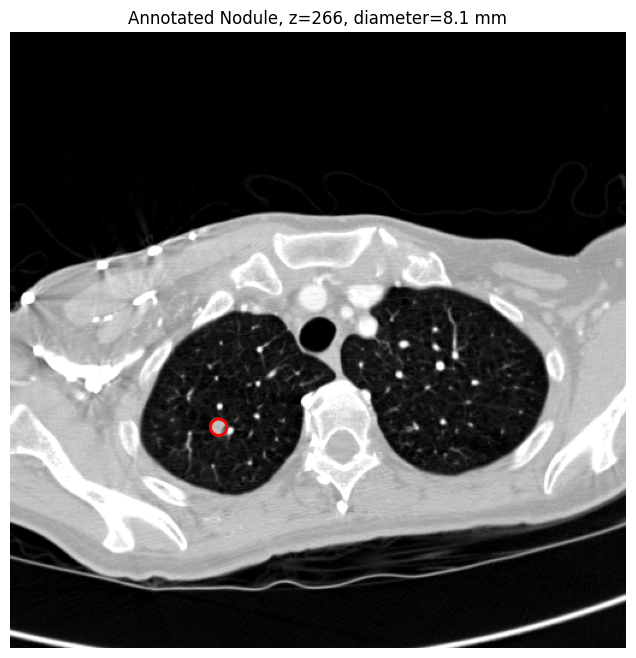

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/clean_notebook_annotated_nodule.png


In [27]:
# Visualize the annotated nodule on the axial slice

slice_2d = ct_array[voxel_z]

plt.figure(figsize=(8, 8))
plt.imshow(slice_2d, cmap="gray", vmin=-1000, vmax=400)

plt.scatter(
    voxel_x,
    voxel_y,
    s=140,
    facecolors="none",
    edgecolors="red",
    linewidths=2,
)

plt.title(f"Annotated Nodule, z={voxel_z}, diameter={diameter_mm:.1f} mm")
plt.axis("off")

output_path = FIGURES_DIR / "clean_notebook_annotated_nodule.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", output_path)

# 10. Extract a 3D Patch

In [28]:
# Extract a 3D patch around the annotated nodule

patch_3d = extract_patch(
    volume=ct_array,
    voxel_x=voxel_x,
    voxel_y=voxel_y,
    voxel_z=voxel_z,
    patch_size=64,
)

print("Patch shape:", patch_3d.shape)
print("Patch min HU:", patch_3d.min())
print("Patch max HU:", patch_3d.max())
print("Patch mean HU:", patch_3d.mean())

Patch shape: (64, 64, 64)
Patch min HU: -1000
Patch max HU: 3000
Patch mean HU: -724.4879264831543


# 11. Normalize the 3D Patch

In [29]:
# Normalize the patch for neural network input

patch_normalized = normalize_hu(patch_3d)

print("Original patch min/max:", patch_3d.min(), patch_3d.max())
print("Normalized patch min/max:", patch_normalized.min(), patch_normalized.max())
print("Normalized patch shape:", patch_normalized.shape)
print("Normalized patch dtype:", patch_normalized.dtype)

Original patch min/max: -1000 3000
Normalized patch min/max: 0.0 1.0
Normalized patch shape: (64, 64, 64)
Normalized patch dtype: float32


# 12. Visualize 3D Patch Slices

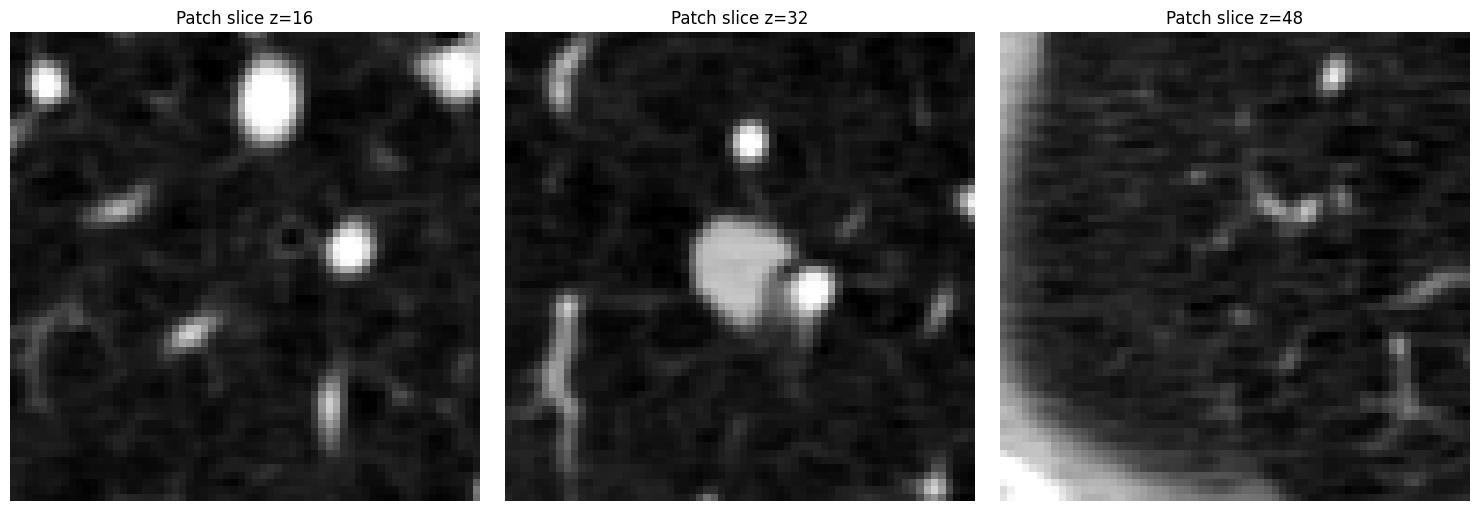

Saved figure: /mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/outputs/figures/clean_notebook_3d_patch_slices.png


In [30]:
# Visualize several axial slices from the normalized 3D patch

slice_indices = [
    patch_normalized.shape[0] // 4,
    patch_normalized.shape[0] // 2,
    3 * patch_normalized.shape[0] // 4,
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx in zip(axes, slice_indices):
    ax.imshow(patch_normalized[idx], cmap="gray")
    ax.set_title(f"Patch slice z={idx}")
    ax.axis("off")

plt.tight_layout()

output_path = FIGURES_DIR / "clean_notebook_3d_patch_slices.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", output_path)

# 13. Analyze Candidate Class Balance

In [31]:
# Analyze class balance in available candidates

class_counts = available_candidates["class"].value_counts()

print(class_counts)

print()
print("Negative candidates:", class_counts.get(0, 0))
print("Positive candidates:", class_counts.get(1, 0))
print("Positive ratio:", class_counts.get(1, 0) / len(available_candidates))

class
0    165568
1       433
Name: count, dtype: int64

Negative candidates: 165568
Positive candidates: 433
Positive ratio: 0.002608418021578183


# Conclusions

This notebook explored the LUNA16 dataset and verified the complete preprocessing pipeline.

The following steps were completed:

- Loaded CT volumes.
- Loaded annotations and candidates.
- Filtered available CT scans.
- Converted world coordinates to voxel coordinates.
- Visualized a radiologist-annotated nodule.
- Extracted a 64×64×64 3D patch.
- Normalized Hounsfield Units.
- Investigated class imbalance.

The preprocessing utilities were moved to the `src/` package for reuse in future notebooks and training code.

# 14. Test LunaDataset

In [32]:
from src.data.luna_dataset import LunaDataset

dataset = LunaDataset(
    candidates_path=candidates_path,
    data_dir=DATA_DIR,
    patch_size=64,
)

image, label = dataset[0]

print("Dataset size:", len(dataset))
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Label:", label)


# from src.data.luna_dataset import LunaDataset

# dataset = LunaDataset(
#     candidates_path=candidates_path,
#     mhd_files=mhd_files,
#     available_series_uids=available_series_uids,
#     patch_size=64,
# )

# print("Dataset size:", len(dataset))

# sample = dataset[0]

# sample

Dataset size: 166001
Image shape: torch.Size([1, 64, 64, 64])
Image dtype: torch.float32
Label: tensor(0)


In [33]:
# import importlib
# import src.data.preprocessing

# importlib.reload(src.data.preprocessing)

# from src.data.preprocessing import load_ct_volume

In [34]:
from src.data.preprocessing import load_ct_volume

volume, origin2, spacing2 = load_ct_volume(ct_path)

print("Volume shape:", volume.shape)
print("Origin:", origin2)
print("Spacing:", spacing2)

Volume shape: (321, 512, 512)
Origin: [-120.04947     9.480416 -657.      ]
Spacing: [0.5566406 0.5566406 1.       ]


In [35]:
from src.data.preprocessing import find_ct_path

ct_path2 = find_ct_path(
    series_uid=series_uid,
    mhd_files=mhd_files,
)

print(ct_path2)
print()
print("Same file:", ct_path == ct_path2)

/mnt/4086152D86152546/MedProjects/luna16-nodule-detection-3dcnn/data/raw/LUNA16/subset2/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405.mhd

Same file: True
